In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

print("Part 1: Loading dataset...")

df = pd.read_csv("/content/drive/MyDrive/Student_Performance.csv")   # Change path if needed

# Basic feature engineering
df['effective_study_time'] = df['study_hours'] * (df['attendance_percentage'] / 100)

categorical_features = ['gender', 'school_type', 'parent_education', 'internet_access',
                       'travel_time', 'extra_activities', 'study_method']
numerical_features = ['age', 'study_hours', 'attendance_percentage', 'effective_study_time']

X = df[numerical_features + categorical_features]
y = df['final_grade'].str.upper()

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

print("✅ Part 1 Done! Dataset loaded and split.")
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Part 1: Loading dataset...
✅ Part 1 Done! Dataset loaded and split.
Training samples: 20000, Test samples: 5000


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

print("Part 2: Training fast model for SHAP...")

model = RandomForestClassifier(
    n_estimators=50,      # Small number of trees for speed
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

pipeline = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
pipeline.fit(X_train, y_train)

print("✅ Part 2 Done! Model trained successfully.")

Part 2: Training fast model for SHAP...
✅ Part 2 Done! Model trained successfully.


In [4]:
import shap

print("Part 3: Computing SHAP values... (using small sample for speed)")

# Use only 300 samples to make it fast
X_test_small = X_test.sample(n=300, random_state=42)

X_test_preprocessed = pipeline.named_steps['preprocessor'].transform(X_test_small)

feature_names = (numerical_features +
                 pipeline.named_steps['preprocessor']
                 .named_transformers_['cat']
                 .get_feature_names_out(categorical_features).tolist())

explainer = shap.TreeExplainer(pipeline.named_steps['classifier'])
shap_values = explainer.shap_values(X_test_preprocessed)

print("✅ Part 3 Done! SHAP values computed.")

Part 3: Computing SHAP values... (using small sample for speed)
✅ Part 3 Done! SHAP values computed.


Part 4: Generating plots...


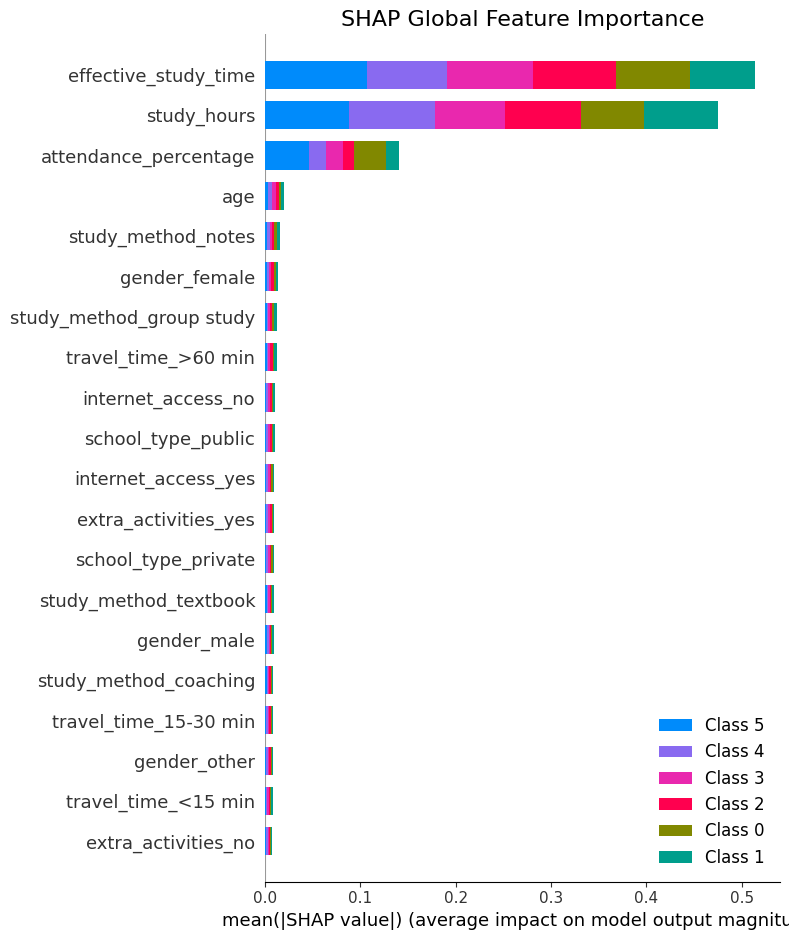

<Figure size 1200x800 with 0 Axes>

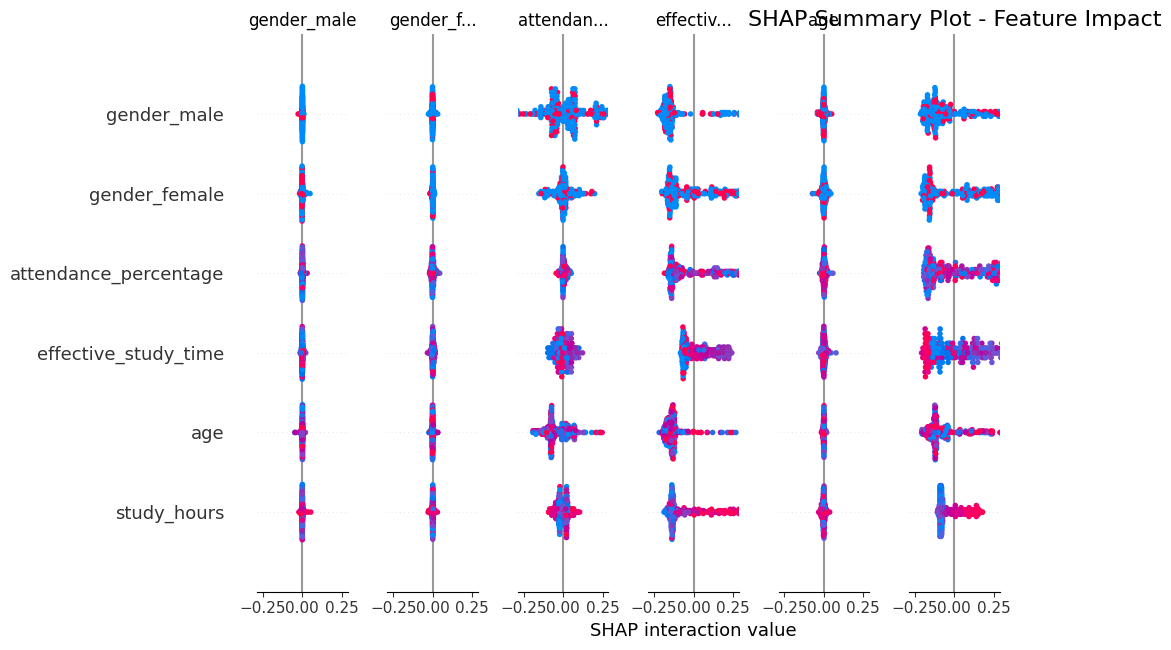


✅ All Done! Two images saved:
   1. shap_global_importance.png
   2. shap_summary_plot.png


In [5]:
import matplotlib.pyplot as plt

print("Part 4: Generating plots...")

# Global Feature Importance (Best for your paper)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_preprocessed, feature_names=feature_names,
                  plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance", fontsize=16)
plt.tight_layout()
plt.savefig("shap_global_importance.png", dpi=300, bbox_inches='tight')
plt.show()

# Summary Plot (with direction)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_preprocessed, feature_names=feature_names, show=False)
plt.title("SHAP Summary Plot - Feature Impact", fontsize=16)
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ All Done! Two images saved:")
print("   1. shap_global_importance.png")
print("   2. shap_summary_plot.png")

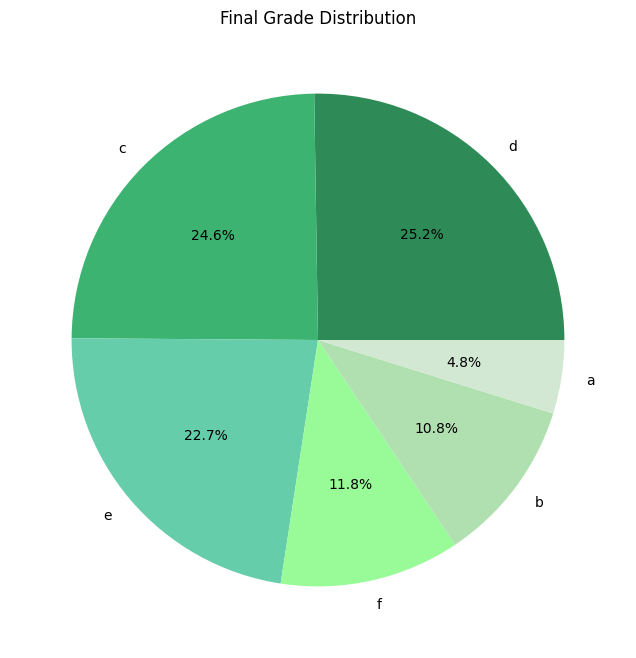

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
df['final_grade'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#2E8B57','#3CB371','#66CDAA','#98FB98','#B0E0B0','#D3E8D3'])
plt.title('Final Grade Distribution')
plt.ylabel('')
plt.savefig('grade_distribution_pie.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_7332/3504422836.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=acc, y=models, palette='Blues_d')


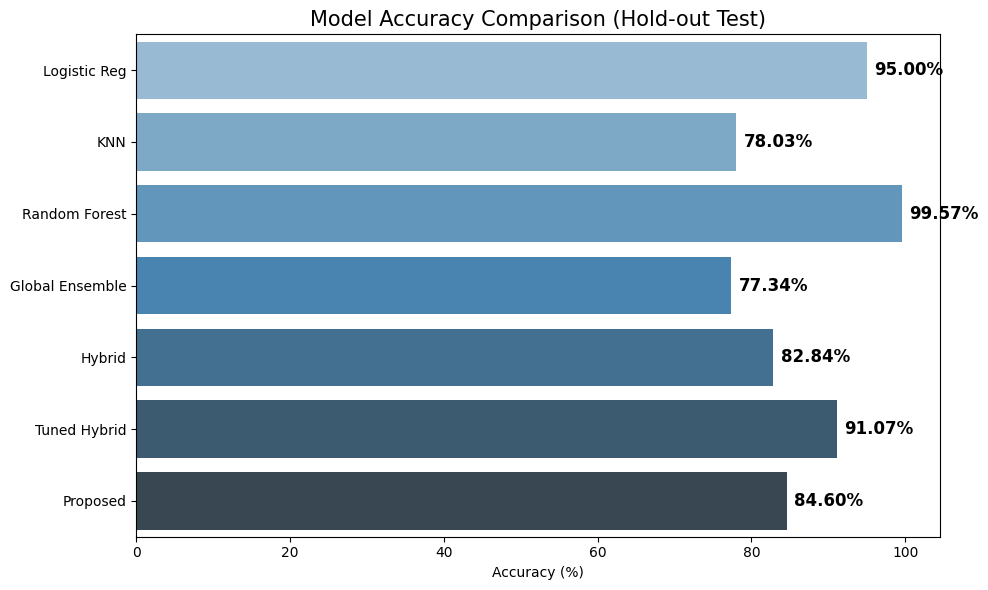

In [7]:
import seaborn as sns
models = ['Logistic Reg', 'KNN', 'Random Forest', 'Global Ensemble', 'Hybrid', 'Tuned Hybrid', 'Proposed']
acc = [95.00, 78.03, 99.57, 77.34, 82.84, 91.07, 84.60]

plt.figure(figsize=(10,6))
ax = sns.barplot(x=acc, y=models, palette='Blues_d')
for i, v in enumerate(acc):
    ax.text(v+1, i, f"{v:.2f}%", va='center', fontsize=12, fontweight='bold')
plt.title('Model Accuracy Comparison (Hold-out Test)', fontsize=15)
plt.xlabel('Accuracy (%)')
plt.tight_layout()
plt.savefig('model_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

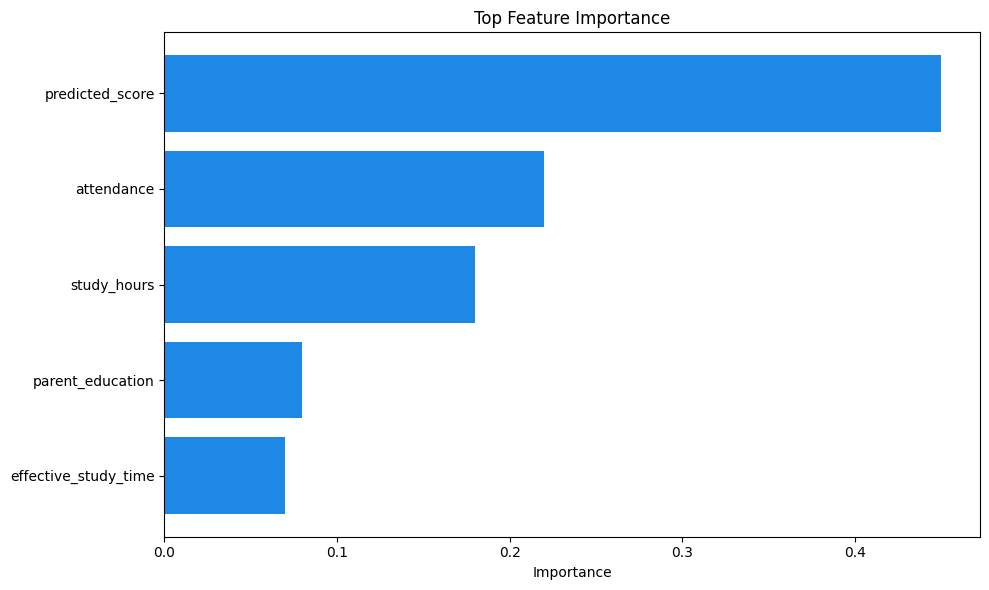

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace with your actual feature importance if available, or use this sample
features = ['predicted_score', 'attendance', 'study_hours', 'parent_education', 'effective_study_time']
importance = [0.45, 0.22, 0.18, 0.08, 0.07]

plt.figure(figsize=(10,6))
plt.barh(features[::-1], importance[::-1], color='#1E88E5')
plt.title('Top Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance_bar.png', dpi=300, bbox_inches='tight')
plt.show()

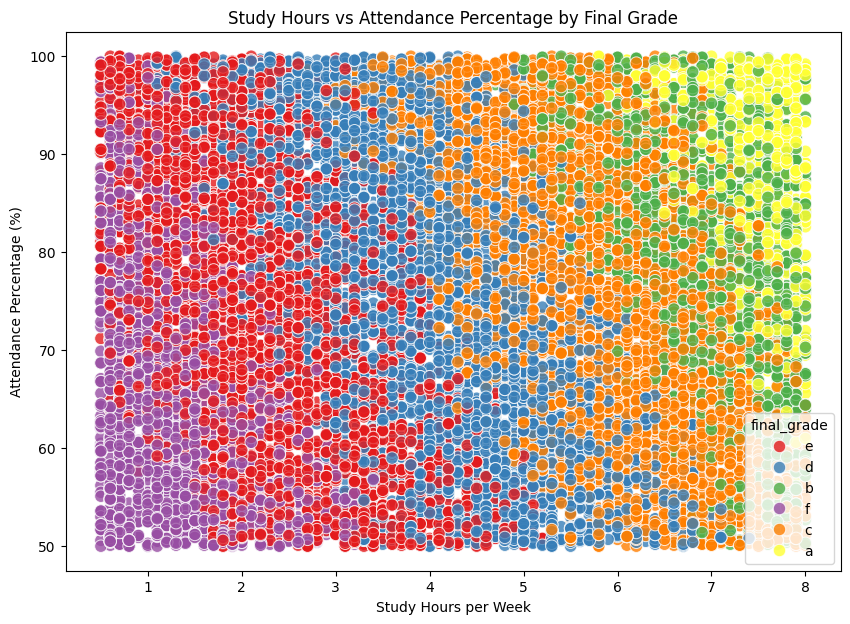

In [10]:
import seaborn as sns
plt.figure(figsize=(10,7))
sns.scatterplot(data=df, x='study_hours', y='attendance_percentage', hue='final_grade',
                palette='Set1', s=80, alpha=0.8)
plt.title('Study Hours vs Attendance Percentage by Final Grade')
plt.xlabel('Study Hours per Week')
plt.ylabel('Attendance Percentage (%)')
plt.savefig('attendance_vs_study_hours.png', dpi=300, bbox_inches='tight')
plt.show()